<a href="https://colab.research.google.com/github/leendaifallah/Airline_passenger_satisfaction/blob/main/Airline_%20satisfaction_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
import kagglehub
path = kagglehub.dataset_download("teejmahal20/airline-passenger-satisfaction")

Using Colab cache for faster access to the 'airline-passenger-satisfaction' dataset.


In [25]:
import pandas as pd
import os

files = os.listdir(path)
train_file = [f for f in files if 'train.csv' in f][0]
file_path = os.path.join(path, train_file)

df = pd.read_csv(file_path)

df.drop(['Unnamed: 0', 'id'], axis=1, errors='ignore', inplace=True)

print("Data Loaded Successfully from KaggleHub!")
print(f"Dataset Shape: {df.shape}")
df.head()


Data Loaded Successfully from KaggleHub!
Dataset Shape: (103904, 23)


,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [26]:
missing_data = df.isnull().sum()
print("Missing Values per Column:")
print(missing_data[missing_data > 0])

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nTarget Variable Distribution:")
print(df['satisfaction'].value_counts(normalize=True) * 100)


Missing Values per Column:
Arrival Delay in Minutes    310
dtype: int64

Duplicate Rows: 0

Target Variable Distribution:
satisfaction
neutral or dissatisfied    56.666731
satisfied                  43.333269
Name: proportion, dtype: float64


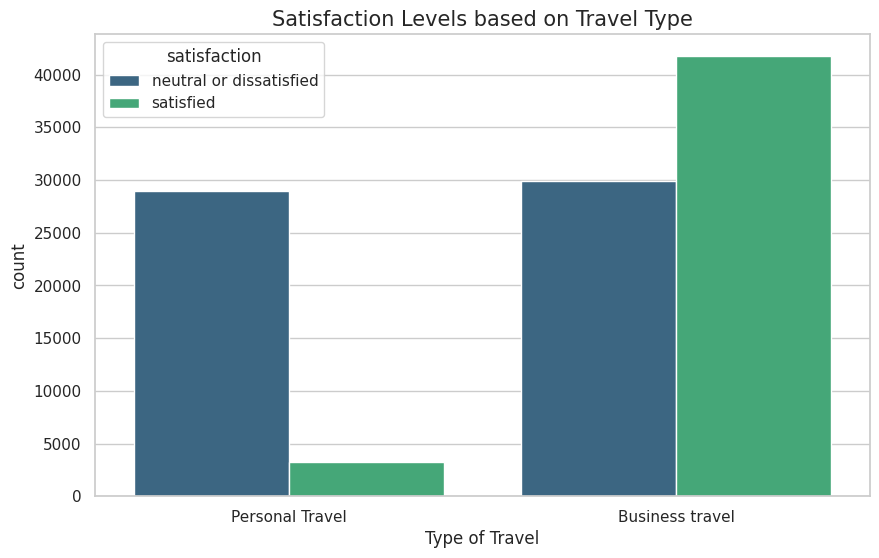

Missing values now: 0


In [27]:
# 1. Fill missing values with the median
df['Arrival Delay in Minutes'] = df['Arrival Delay in Minutes'].fillna(df['Arrival Delay in Minutes'].median())


import seaborn as sns
import matplotlib.pyplot as plt
sns.set_theme(style="whitegrid")


plt.figure(figsize=(10, 6))
sns.countplot(x='Type of Travel', hue='satisfaction', data=df, palette='viridis')
plt.title('Satisfaction Levels based on Travel Type', fontsize=15)
plt.show()

#Check missing values again
print("Missing values now:", df['Arrival Delay in Minutes'].isnull().sum())


In [30]:
import pandas as pd
import numpy as np
import os
import kagglehub
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. Download and Load Data
path = kagglehub.dataset_download("teejmahal20/airline-passenger-satisfaction")
files = os.listdir(path)
train_file = [f for f in files if 'train.csv' in f][0]
df = pd.read_csv(os.path.join(path, train_file))

# 2. Clean Data
df.drop(['Unnamed: 0', 'id'], axis=1, errors='ignore', inplace=True)
df['Arrival Delay in Minutes'] = df['Arrival Delay in Minutes'].fillna(df['Arrival Delay in Minutes'].median())

# 3 (Convert text to numbers)
df['satisfaction'] = df['satisfaction'].map({'neutral or dissatisfied': 0, 'satisfied': 1})
df = pd.get_dummies(df, columns=['Gender', 'Customer Type', 'Type of Travel', 'Class'], drop_first=True)


X = df.drop('satisfaction', axis=1)
y = df['satisfaction']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

#Output Results
y_pred = model.predict(X_test)
print(f"Final Model Accuracy: {accuracy_score(y_test, y_pred):.2%}")
print("\nSuccess! Your model is fully trained.")


Using Colab cache for faster access to the 'airline-passenger-satisfaction' dataset.
Final Model Accuracy: 96.18%

Success! Your model is fully trained.


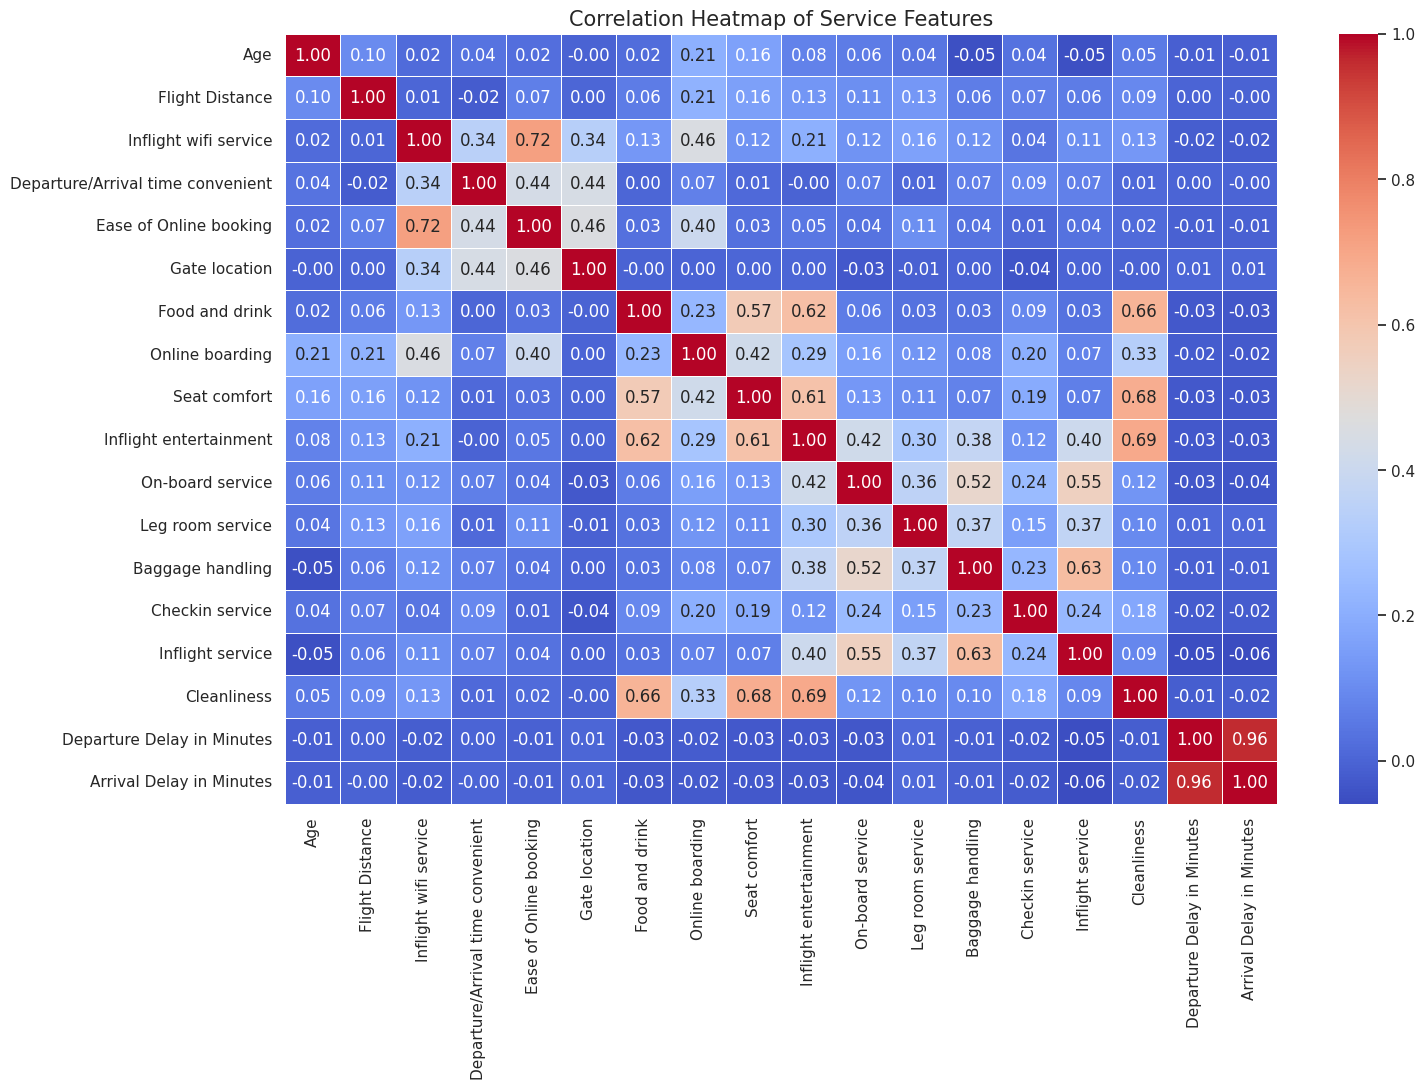

In [31]:
import seaborn as sns
import matplotlib.pyplot as plt


cols_to_plot = ['Age', 'Flight Distance', 'Inflight wifi service',
                'Departure/Arrival time convenient', 'Ease of Online booking',
                'Gate location', 'Food and drink', 'Online boarding',
                'Seat comfort', 'Inflight entertainment', 'On-board service',
                'Leg room service', 'Baggage handling', 'Checkin service',
                'Inflight service', 'Cleanliness', 'Departure Delay in Minutes',
                'Arrival Delay in Minutes']

plt.figure(figsize=(16, 10))
sns.heatmap(df[cols_to_plot].corr(), annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap of Service Features', fontsize=15)
plt.show()


/tmp/ipython-input-3552612140.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='magma')


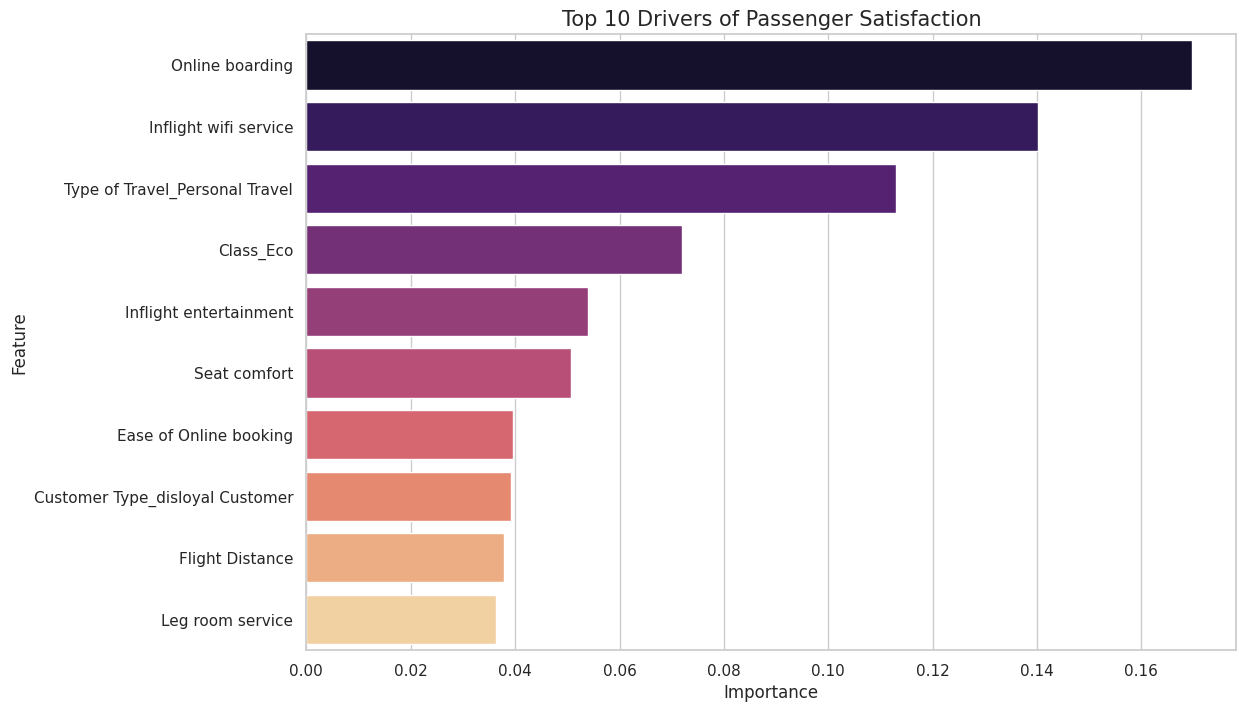

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

importances = model.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='magma')
plt.title('Top 10 Drivers of Passenger Satisfaction', fontsize=15)
plt.show()
